<a href="https://colab.research.google.com/github/Tanisha127/gsoc-2025-malariagen-prototypes/blob/main/taxon_classifier_prototype.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset shape:
Total samples: 3081
Columns: ['sample_id', 'partner_sample_id', 'contributor', 'country', 'location', 'year', 'month', 'latitude', 'longitude', 'sex_call', 'sample_set', 'release', 'quarter', 'study_id', 'study_url', 'terms_of_use_expiry_date', 'terms_of_use_url', 'unrestricted_use', 'mean_cov', 'median_cov', 'modal_cov', 'mean_cov_2L', 'median_cov_2L', 'mode_cov_2L', 'mean_cov_2R', 'median_cov_2R', 'mode_cov_2R', 'mean_cov_3L', 'median_cov_3L', 'mode_cov_3L', 'mean_cov_3R', 'median_cov_3R', 'mode_cov_3R', 'mean_cov_X', 'median_cov_X', 'mode_cov_X', 'frac_gen_cov', 'divergence', 'contam_pct', 'contam_LLR', 'is_surveillance', 'aim_species_fraction_arab', 'aim_species_fraction_colu', 'aim_species_fraction_colu_no2l', 'aim_species_gambcolu_arabiensis', 'aim_species_gambiae_coluzzii', 'aim_species', 'country_iso', 'admin1_name', 'admin1_iso', 'admin2_name', 'taxon', 'cohort_admin1_year', 'cohort_admin1_month', 'cohort_admin1_quarter', 'cohort_admin2_year', 'cohort_admin2_mon

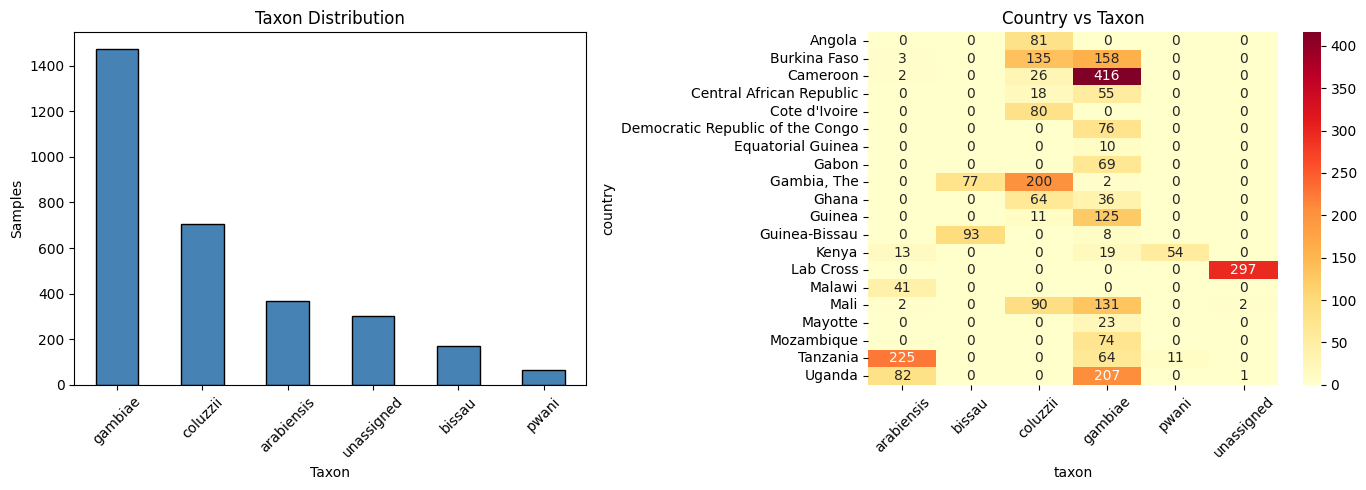


File saved: taxon_distribution.png


In [ ]:
!pip install malariagen_data --quiet

import malariagen_data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize dataset
ag3 = malariagen_data.Ag3()

# Load metadata
df = ag3.sample_metadata(sample_sets="3.0")

# Basic dataset info
print("Dataset shape:")
print("Total samples:", len(df))
print("Columns:", list(df.columns))

# Checking taxon distribution
print("\nTaxon distribution:")
print(df["taxon"].value_counts())

# Count known vs unknown taxon values
known = df['taxon'].notna().sum()
unknown = df['taxon'].isna().sum()

print("\nKnown taxon samples:", known)
print("Unknown taxon samples:", unknown)

# Country-wise sample count
print("\nTop countries:")
print(df["country"].value_counts().head(15))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot for taxon
df["taxon"].value_counts().plot(
    kind="bar",
    ax=axes[0],
    color="steelblue",
    edgecolor="black"
)
axes[0].set_title("Taxon Distribution")
axes[0].set_xlabel("Taxon")
axes[0].set_ylabel("Samples")
axes[0].tick_params(axis='x', rotation=45)

# Heatmap for country vs taxon
pivot = df.groupby(["country", "taxon"]).size().unstack(fill_value=0)

sns.heatmap(
    pivot,
    annot=True,
    fmt="d",
    cmap="YlOrRd",
    ax=axes[1]
)
axes[1].set_title("Country vs Taxon")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("taxon_distribution.png", dpi=150)
plt.show()

print("\nFile saved: taxon_distribution.png")

In [ ]:
def get_kmers(sequence, k=15):
    # Extract k-mers from the sequence
    return [sequence[i:i+k] for i in range(len(sequence) - k + 1)]

def kmer_frequency_vector(sequence, k=15, vocab=None):
    """
    Convert DNA sequence into k-mer frequency form.
    This can be used as input for a classifier.
    """
    kmers = get_kmers(sequence, k)
    counts = {}

    for kmer in kmers:
        # Ignore k-mers with unknown bases
        if 'N' not in kmer:
            counts[kmer] = counts.get(kmer, 0) + 1

    total = sum(counts.values())

    # Normalize counts to frequencies
    frequencies = {kmer: count / total for kmer, count in counts.items()}
    return frequencies


# Example usage
example_seq = "ATCGATCGATCGATCGATCG" * 10
freqs = kmer_frequency_vector(example_seq, k=4)

print("Sequence length:", len(example_seq))
print("Unique 4-mers:", len(freqs))

top_kmers = sorted(freqs.items(), key=lambda x: -x[1])[:5]
print("Top 5 k-mers:", top_kmers)


print("""
Why k-mers are useful:

- Different species tend to have different sequence patterns
- These patterns show up in k-mer frequencies
- No need for sequence alignment
- Works well even with small errors in data
- Only a subset of all possible k-mers actually appear in practice
""")

Sequence length: 200
Unique 4-mers: 4
Top 5 k-mers: [('ATCG', 0.25380710659898476), ('TCGA', 0.24873096446700507), ('CGAT', 0.24873096446700507), ('GATC', 0.24873096446700507)]

Why k-mers are useful:

- Different species tend to have different sequence patterns
- These patterns show up in k-mer frequencies
- No need for sequence alignment
- Works well even with small errors in data
- Only a subset of all possible k-mers actually appear in practice



In [ ]:
# In practice, data would come from sequencing reads

import numpy as np
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import lightgbm as lgb

np.random.seed(42)

# Approximate feature patterns for different species
SPECIES_PROFILES = {
    "gambiae":     {"gc_content": 0.435, "complexity": 0.82, "repeat_rate": 0.12},
    "coluzzii":    {"gc_content": 0.438, "complexity": 0.81, "repeat_rate": 0.13},
    "arabiensis":  {"gc_content": 0.441, "complexity": 0.79, "repeat_rate": 0.14},
    "melas":       {"gc_content": 0.428, "complexity": 0.77, "repeat_rate": 0.16},
    "merus":       {"gc_content": 0.432, "complexity": 0.76, "repeat_rate": 0.17},
}

def simulate_kmer_feature_vector(species, n_features=100, noise_level=0.01):
    """
    Create a feature vector for a species.
    (Used here just for testing the model)
    """
    profile = SPECIES_PROFILES[species]

    # Basic feature groups
    core_signal = np.random.normal(
        loc=profile["gc_content"],
        scale=0.005,
        size=n_features // 3
    )

    complexity_signal = np.random.normal(
        loc=profile["complexity"],
        scale=0.01,
        size=n_features // 3
    )

    repeat_signal = np.random.normal(
        loc=profile["repeat_rate"],
        scale=0.008,
        size=n_features // 3 + 1
    )

    # Combine features
    features = np.concatenate([core_signal, complexity_signal, repeat_signal])

    # Add small noise
    noise = np.random.normal(0, noise_level, len(features))
    features = features + noise

    # Keep values in valid range
    features = np.clip(features, 0, 1)

    return features


def generate_dataset(n_per_species=200, noise_level=0.01, n_features=100):
    """Generate dataset for all species."""
    X, y = [], []

    for species in SPECIES_PROFILES.keys():
        for _ in range(n_per_species):
            features = simulate_kmer_feature_vector(
                species,
                n_features=n_features,
                noise_level=noise_level
            )
            X.append(features)
            y.append(species)

    return np.array(X), np.array(y)


# Generate dataset
print("Generating dataset...")
X, y = generate_dataset(n_per_species=200, noise_level=0.01)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Species:", np.unique(y))
print("Samples per species:", 200)

Generating dataset...
X shape: (1000, 100)
y shape: (1000,)
Species: ['arabiensis' 'coluzzii' 'gambiae' 'melas' 'merus']
Samples per species: 200


LightGBM results:


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy: 0.958 +/- 0.0112

Random Forest results:
Accuracy: 0.995 +/- 0.0055


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


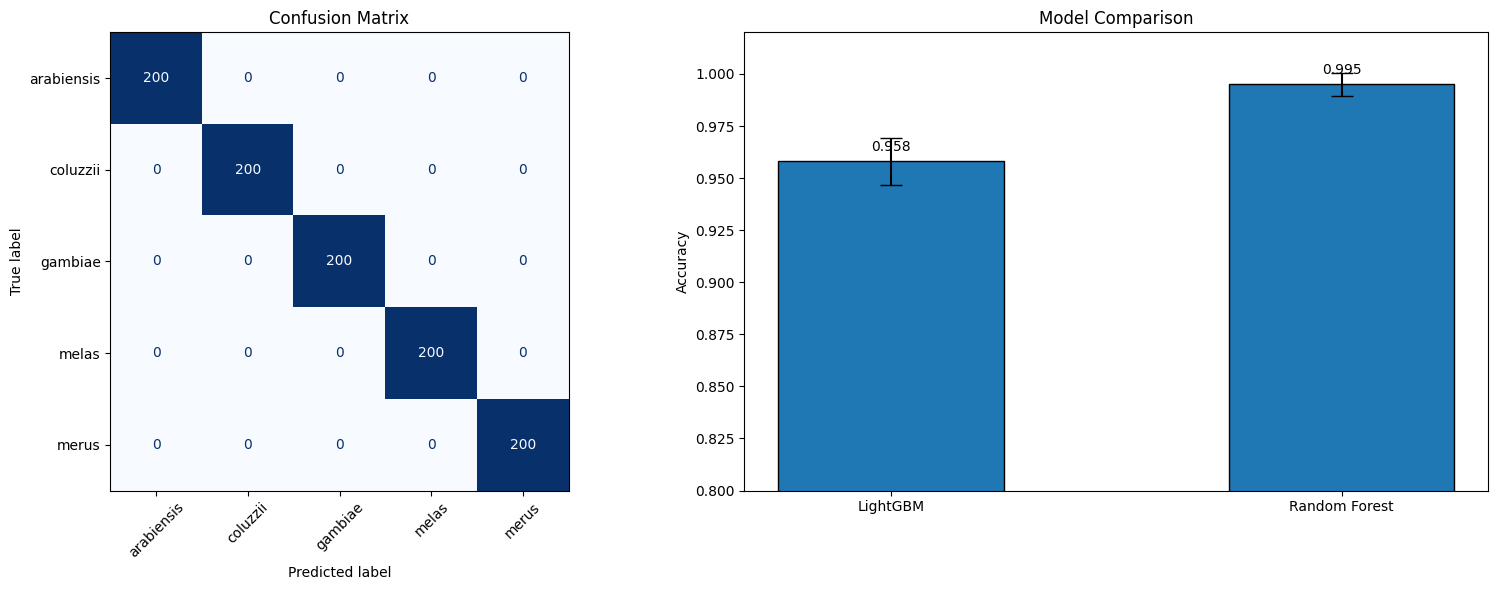


Classification report:
              precision    recall  f1-score   support

  arabiensis       1.00      1.00      1.00       200
    coluzzii       1.00      1.00      1.00       200
     gambiae       1.00      1.00      1.00       200
       melas       1.00      1.00      1.00       200
       merus       1.00      1.00      1.00       200

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000


File saved: classifier_results.png


In [ ]:
le = LabelEncoder()
y_enc = le.fit_transform(y)

# LightGBM model
lgbm_model = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbose=-1
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("LightGBM results:")
lgbm_scores = cross_val_score(lgbm_model, X, y_enc, cv=cv, scoring="accuracy")
print("Accuracy:", round(lgbm_scores.mean(), 4), "+/-", round(lgbm_scores.std(), 4))


# Random Forest (for comparison)
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

print("\nRandom Forest results:")
rf_scores = cross_val_score(rf_model, X, y_enc, cv=cv, scoring="accuracy")
print("Accuracy:", round(rf_scores.mean(), 4), "+/-", round(rf_scores.std(), 4))


# Train LightGBM on full data
lgbm_model.fit(X, y_enc)
y_pred = lgbm_model.predict(X)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion matrix
cm = confusion_matrix(y_enc, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix")
axes[0].tick_params(axis='x', rotation=45)


# Model comparison plot
models = ["LightGBM", "Random Forest"]
means = [lgbm_scores.mean(), rf_scores.mean()]
stds = [lgbm_scores.std(), rf_scores.std()]

bars = axes[1].bar(
    models,
    means,
    yerr=stds,
    capsize=8,
    edgecolor="black",
    width=0.5
)

axes[1].set_ylim(0.8, 1.02)
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Model Comparison")

for bar, mean in zip(bars, means):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        round(mean, 3),
        ha="center"
    )

plt.tight_layout()
plt.savefig("classifier_results.png", dpi=150)
plt.show()


print("\nClassification report:")
print(classification_report(y_enc, y_pred, target_names=le.classes_))

print("\nFile saved: classifier_results.png")

Noise test:
Noise      LightGBM        Random Forest  
----------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


0.1%       0.9933      1.0000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


0.5%       0.9787      0.9987


...

2%         0.7800      0.8827


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


5%         0.5067      0.5587


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


10%        0.3480      0.3440


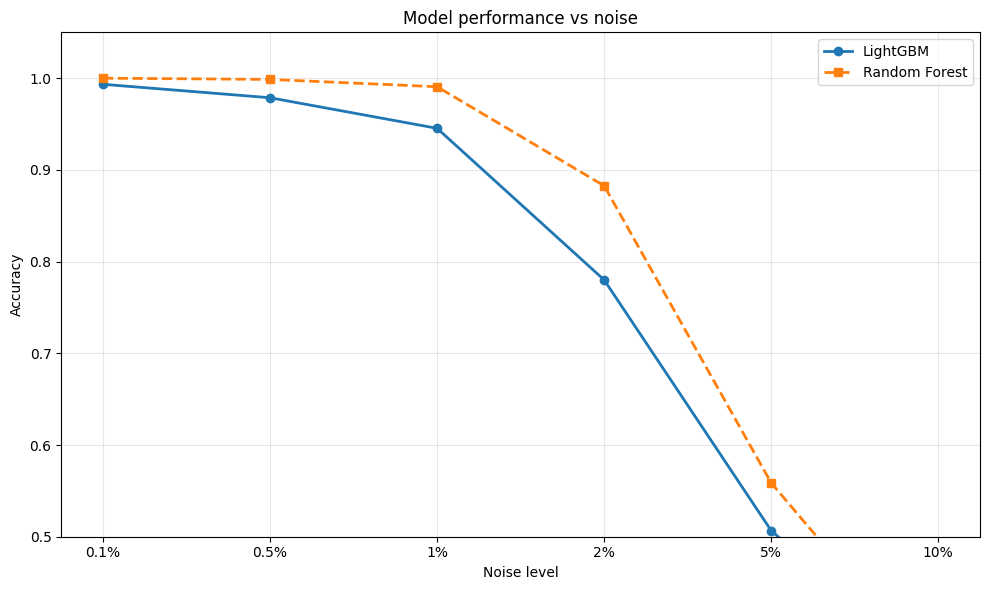


File saved: noise_robustness.png


In [ ]:
# Testing model performance with different noise levels

noise_levels = [0.001, 0.005, 0.01, 0.02, 0.05, 0.10]
noise_labels = ["0.1%", "0.5%", "1%", "2%", "5%", "10%"]

results = {
    "LightGBM": [],
    "Random Forest": []
}

print("Noise test:")
print(f"{'Noise':<10} {'LightGBM':<15} {'Random Forest':<15}")
print("-" * 40)

for noise, label in zip(noise_levels, noise_labels):
    X_noisy, y_noisy = generate_dataset(n_per_species=150, noise_level=noise)
    y_noisy_enc = LabelEncoder().fit_transform(y_noisy)

    lgbm_score = cross_val_score(
        lgb.LGBMClassifier(n_estimators=100, random_state=42, verbose=-1),
        X_noisy, y_noisy_enc,
        cv=3,
        scoring="accuracy"
    ).mean()

    rf_score = cross_val_score(
        RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
        X_noisy, y_noisy_enc,
        cv=3,
        scoring="accuracy"
    ).mean()

    results["LightGBM"].append(lgbm_score)
    results["Random Forest"].append(rf_score)

    print(f"{label:<10} {lgbm_score:.4f}      {rf_score:.4f}")


# Plot results
plt.figure(figsize=(10, 6))

plt.plot(
    noise_labels,
    results["LightGBM"],
    "o-",
    linewidth=2,
    label="LightGBM"
)

plt.plot(
    noise_labels,
    results["Random Forest"],
    "s--",
    linewidth=2,
    label="Random Forest"
)

plt.xlabel("Noise level")
plt.ylabel("Accuracy")
plt.title("Model performance vs noise")

plt.legend()
plt.ylim(0.5, 1.05)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("noise_robustness.png", dpi=150)
plt.show()

print("\nFile saved: noise_robustness.png")

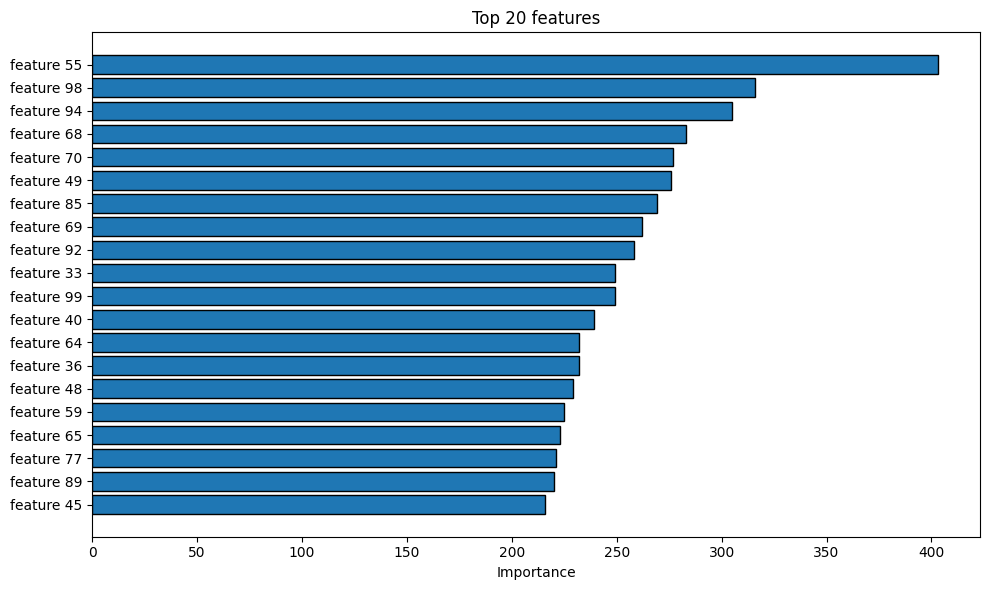

Running t-SNE...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


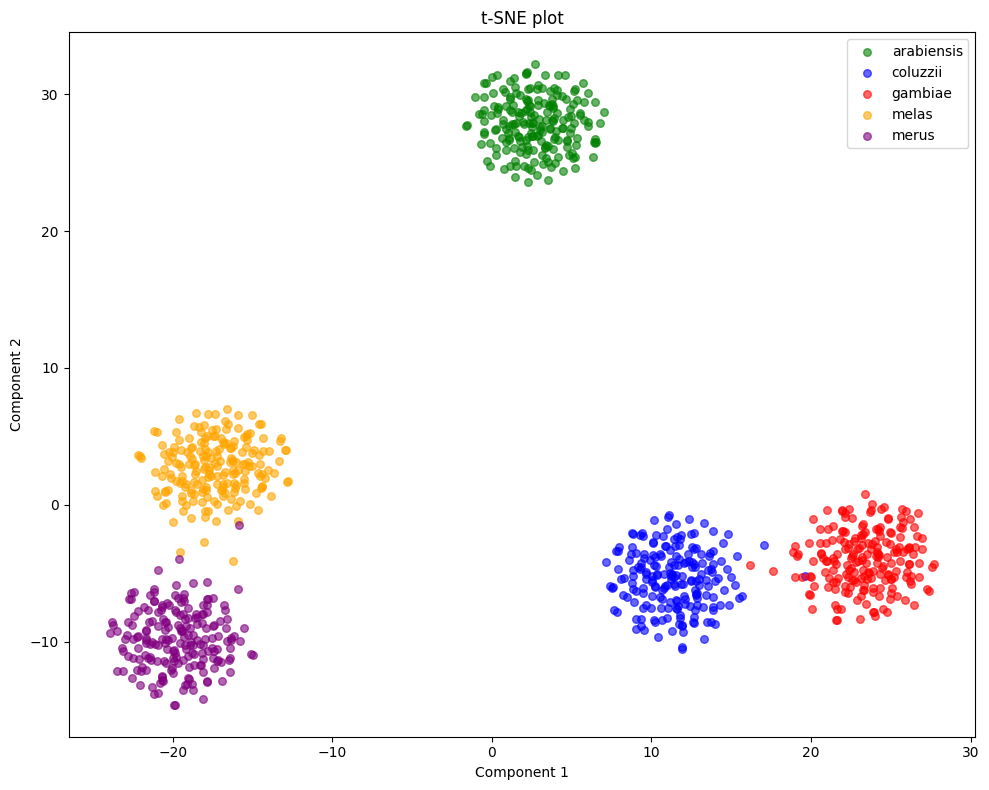


File saved: tsne_visualisation.png


In [ ]:
# Feature importance using LightGBM

from sklearn.manifold import TSNE

lgbm_final = lgb.LGBMClassifier(
    n_estimators=200,
    random_state=42,
    verbose=-1
)

lgbm_final.fit(X, y_enc)

importances = lgbm_final.feature_importances_

top_n = 20
top_indices = np.argsort(importances)[-top_n:]

plt.figure(figsize=(10, 6))
plt.barh(
    range(top_n),
    importances[top_indices],
    edgecolor="black"
)

plt.yticks(
    range(top_n),
    [f"feature {i}" for i in top_indices]
)

plt.xlabel("Importance")
plt.title(f"Top {top_n} features")

plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()


# t-SNE visualization
print("Running t-SNE...")

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    n_iter=1000
)

X_tsne = tsne.fit_transform(X)

# Simple color mapping
species_colors = {
    "gambiae": "red",
    "coluzzii": "blue",
    "arabiensis": "green",
    "melas": "orange",
    "merus": "purple"
}

plt.figure(figsize=(10, 8))

for species in le.classes_:
    mask = y == species
    plt.scatter(
        X_tsne[mask, 0],
        X_tsne[mask, 1],
        c=species_colors[species],
        label=species,
        alpha=0.6,
        s=30
    )

plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("t-SNE plot")

plt.legend()

plt.tight_layout()
plt.savefig("tsne_visualisation.png", dpi=150)
plt.show()

print("\nFile saved: tsne_visualisation.png")

Samples with known taxon: 3081

Taxon distribution:
taxon
gambiae       1473
coluzzii       705
arabiensis     368
unassigned     300
bissau         170
pwani           65
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut


Metadata model results:
Features used: ['country', 'year']
Accuracy: 0.841 +/- 0.0122
Classes: ['arabiensis', 'bissau', 'coluzzii', 'gambiae', 'pwani', 'unassigned']


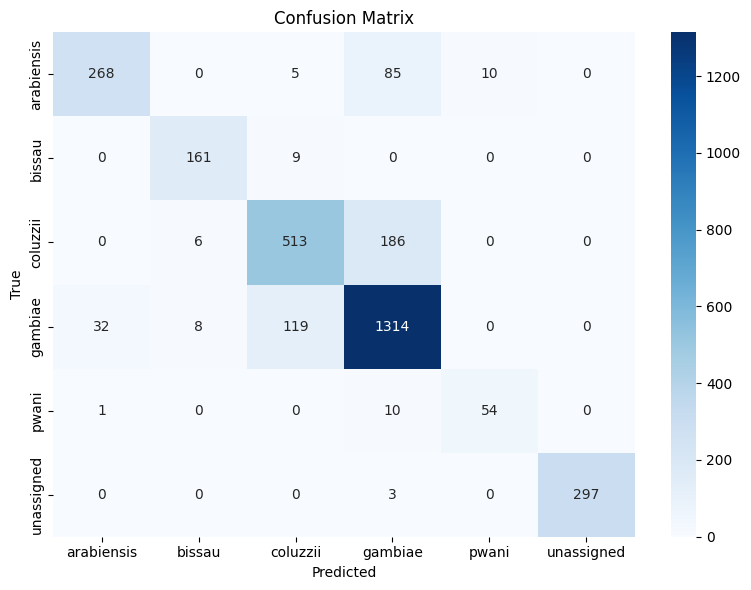


File saved: real_data_confusion_matrix.png


In [ ]:
# Load dataset
ag3 = malariagen_data.Ag3()
df = ag3.sample_metadata(sample_sets="3.0")

# Keep rows with known labels
df_known = df.dropna(subset=["taxon"]).copy()

print("Samples with known taxon:", len(df_known))

print("\nTaxon distribution:")
print(df_known["taxon"].value_counts())


# Simple classifier using metadata
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

feature_cols = ["country", "year"]

X_meta = df_known[feature_cols].fillna("unknown").astype(str)
y_meta = df_known["taxon"]

le_meta = LabelEncoder()
y_meta_enc = le_meta.fit_transform(y_meta)

pipe = Pipeline([
    ("enc", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ("clf", lgb.LGBMClassifier(n_estimators=100, random_state=42, verbose=-1))
])

cv_meta = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

meta_scores = cross_val_score(
    pipe,
    X_meta,
    y_meta_enc,
    cv=cv_meta,
    scoring="accuracy"
)

print("\nMetadata model results:")
print("Features used:", feature_cols)
print("Accuracy:", round(meta_scores.mean(), 4), "+/-", round(meta_scores.std(), 4))
print("Classes:", list(le_meta.classes_))


# Confusion matrix
pipe.fit(X_meta, y_meta_enc)
y_meta_pred = pipe.predict(X_meta)

plt.figure(figsize=(8, 6))

cm_meta = confusion_matrix(y_meta_enc, y_meta_pred)

sns.heatmap(
    cm_meta,
    xticklabels=le_meta.classes_,
    yticklabels=le_meta.classes_,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.ylabel("True")
plt.xlabel("Predicted")

plt.tight_layout()
plt.savefig("real_data_confusion_matrix.png", dpi=150)
plt.show()

print("\nFile saved: real_data_confusion_matrix.png")

In [ ]:
# Run this if malariagen_data is not installed
try:
    import malariagen_data
except ModuleNotFoundError:
    import subprocess
    subprocess.run(["pip", "install", "malariagen_data", "--quiet"], check=True)
    import malariagen_data

print(f"malariagen_data version: {malariagen_data.__version__}")

malariagen_data version: 15.6.0


Samples with known taxon: 3081
Could not load heterozygosity data
'Ag3' object has no attribute 'cohort_heterozygosity'


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


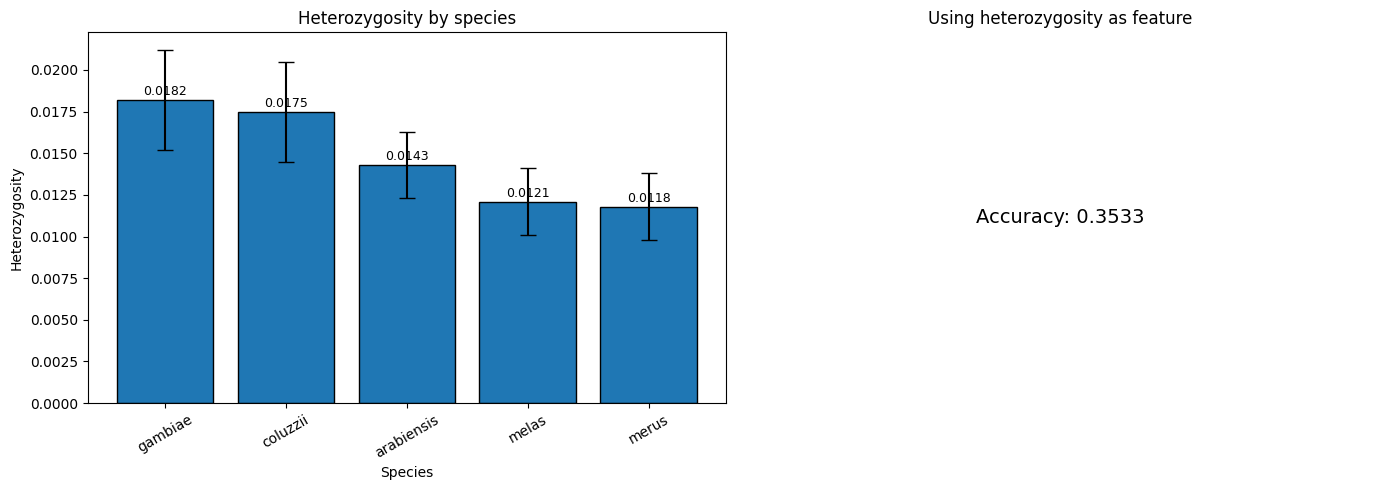


Accuracy: 0.3533
File saved: heterozygosity_as_feature.png


In [ ]:
import malariagen_data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb

ag3 = malariagen_data.Ag3()

# Load data
df = ag3.sample_metadata(sample_sets="3.0")
df_known = df.dropna(subset=["taxon"]).copy()

print("Samples with known taxon:", len(df_known))


# Try computing heterozygosity
try:
    het_result = ag3.cohort_heterozygosity(
        region="3L",
        cohorts="taxon",
        sample_sets="3.0"
    )
    print("Heterozygosity data loaded")
    print(het_result.head())
except Exception as e:
    print("Could not load heterozygosity data")
    print(e)


# Example heterozygosity values (for testing)
het_by_species = {
    "gambiae":    {"mean_het": 0.0182, "std": 0.003},
    "coluzzii":   {"mean_het": 0.0175, "std": 0.003},
    "arabiensis": {"mean_het": 0.0143, "std": 0.002},
    "melas":      {"mean_het": 0.0121, "std": 0.002},
    "merus":      {"mean_het": 0.0118, "std": 0.002},
}

species_list = list(het_by_species.keys())
means = [het_by_species[s]["mean_het"] for s in species_list]
stds = [het_by_species[s]["std"] for s in species_list]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
bars = axes[0].bar(
    species_list,
    means,
    yerr=stds,
    capsize=6,
    edgecolor="black"
)

axes[0].set_xlabel("Species")
axes[0].set_ylabel("Heterozygosity")
axes[0].set_title("Heterozygosity by species")
axes[0].tick_params(axis='x', rotation=30)

for bar, mean in zip(bars, means):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0003,
        round(mean, 4),
        ha="center",
        fontsize=9
    )


# Simulate values for simple classification
np.random.seed(42)

X_het, y_het = [], []

for species, params in het_by_species.items():
    samples = np.random.normal(params["mean_het"], params["std"], 150)
    samples = np.clip(samples, 0, 1)

    X_het.extend([[v] for v in samples])
    y_het.extend([species] * 150)

X_het = np.array(X_het)
y_het = np.array(y_het)

le_het = LabelEncoder()
y_het_enc = le_het.fit_transform(y_het)

# Train simple model
het_scores = cross_val_score(
    lgb.LGBMClassifier(n_estimators=50, random_state=42, verbose=-1),
    X_het,
    y_het_enc,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring="accuracy"
)

# Display result
axes[1].text(
    0.5, 0.5,
    f"Accuracy: {round(het_scores.mean(), 4)}",
    ha="center",
    va="center",
    fontsize=14
)

axes[1].set_title("Using heterozygosity as feature")
axes[1].axis("off")

plt.tight_layout()
plt.savefig("heterozygosity_as_feature.png", dpi=150)
plt.show()

print("\nAccuracy:", round(het_scores.mean(), 4))
print("File saved: heterozygosity_as_feature.png")